In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

from flax import nnx

In [3]:
from diffusion_mri_models import Dti, Ball, Stick, add_mri_noise

In [8]:
class BallAndStick(nnx.Module, experimental_pytree=True):
    
    def __init__(self,num_sticks: int, rngs):
        self.num_sticks = num_sticks
        self.num_components = 1 + num_sticks + 1 # Ball + Sticks + Noise
        # Ball parameters
        self.theta_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))
        self.phi_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))

        self.thetas_stick = []
        self.phis_stick = []
    
        for i in range(num_sticks):
            self.thetas_stick.append(nnx.Param(jax.random.normal(rngs.next(), (3))))
            if i < num_sticks-1:
                self.phis_stick.append(nnx.Param(jax.random.normal(rngs.next(), (1))))

        self.theta_sigma = nnx.Param(jax.random.normal(rngs.next(), (1)))

        

    def __call__(self, component_mask, bvals, bvecs, rng):
        ball = Ball.from_theta(self.theta_ball.value)
        sticks = [Stick.from_theta(theta) for theta in self.thetas_stick]

        phi0 = jax.nn.sigmoid(self.phi_ball.value) * component_mask[0]
        S_ball = ball.signal(bvals, bvecs) * phi0

        S_total = S_ball

        for i, stick in enumerate(sticks[:-1]):
            phi_i =  jax.nn.sigmoid(self.phis_stick[i].value) * (1-phi0) * component_mask[i+1]
            phi0 += phi_i # update the total volume fraction
            S_total += stick.signal(bvals, bvecs)*phi_i

        # Last stick
        if len(sticks) > 0:
            S_total += sticks[-1].signal(bvals, bvecs) * (1-phi0) * component_mask[-2]

        std = jax.nn.sigmoid(self.theta_sigma.value)*0.1 * component_mask[-1]
        S_noisy = add_mri_noise(rng,S_total, std)

        return S_noisy


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [9]:
simulator = BallAndStick(2, nnx.Rngs(0))

bvals = jnp.array([0]*10 + [1000]*90)
bvecs = jax.random.normal(jax.random.key(1), (100,3))
component_mask = jnp.array([1]*simulator.num_components)
component_mask

Array([1, 1, 1, 1], dtype=int32)

In [10]:
component_mask = jnp.array([1,1,1,1])
s = simulator(component_mask, bvals, bvecs, jax.random.key(9))

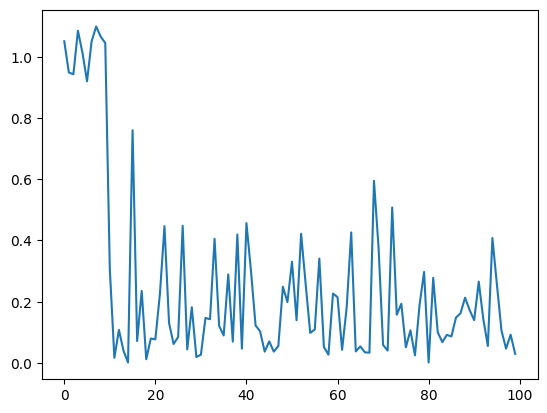

In [11]:
plt.plot(s)

In [135]:
graphdef, thetas = nnx.split(simulator, nnx.Param)
flat_thetas, unflatten = jax.flatten_util.ravel_pytree(thetas)

NUM_AQUISITIONS = 100

def generate_data(key):
    rng_component_mask, rng_params, rng_simulator = jax.random.split(key,3)
    component_mask = jax.random.bernoulli(rng_component_mask, 1., (simulator.num_components,))
    params = jax.random.normal(rng_params, flat_thetas.shape)
    params = unflatten(params)
    f = nnx.merge(graphdef, params)
    S = f(component_mask, bvals, bvecs, rng_simulator)
    return component_mask, params, S

flat_thetas


Array([-1.401,  0.676,  1.88 ,  0.306, -0.795,  0.763, -0.3  , -0.41 ,
        0.113, -0.509], dtype=float32)

In [146]:
from functools import partial


@partial(jax.jit, static_argnums=(1,))  
def batch_sampler(key, batch_size=512):
    keys = jax.random.split(key, batch_size)
    components, thetas, signal= jax.vmap(lambda k:generate_data(k))(keys)
    xs = signal.reshape((batch_size, -1))
    return components, thetas, xs

def train_data_generator(key, batch_size):
    while True:
        key, subkey = jax.random.split(key)
        yield batch_sampler(subkey, batch_size)

train_data = train_data_generator(jax.random.PRNGKey(0), 1024)

In [137]:
    from models import ModelIdentificationDecoder, MLP, Simformer, PyTreeTokenizer, EDM

In [138]:
import jax.flatten_util


_, thetas, xs = next(train_data)

thetas_flatten, tree = jax.tree_util.tree_flatten(thetas)
thetas_flat = jnp.concatenate(thetas_flatten, axis=-1)

In [139]:
embedding_net = MLP([NUM_AQUISITIONS, 100,50], rngs=nnx.Rngs(0))

dims_by_component = [1,1,1,1,3,3]
node_ids = list(range(len(dims_by_component)))
embed_nets = [nnx.Linear(dims_by_component[i], 50, rngs=nnx.Rngs(1),use_bias=False) for i in range(len(dims_by_component))]
decode_nets = [nnx.Linear(100, dims_by_component[i], rngs=nnx.Rngs(2),use_bias=False) for i in range(len(dims_by_component))]

tokenizer = PyTreeTokenizer(dims_by_component, embed_nets, decode_nets, rngs=nnx.Rngs(3))
simformer = Simformer(tokenizer, nnx.Rngs(4), model_dim=100, context_embed=embedding_net)

model = EDM(simformer)
params = nnx.state(model, nnx.Param)

In [140]:
components, thetas, xs = next(train_data)

In [261]:
import optax 

scheduler_lr = optax.cosine_onecycle_schedule(10_000, 5e-4)
optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.ema(0.01), optax.adam(scheduler_lr))

@jax.jit
def loss_fn(params, data, rng):
    components, thetas, xs = data
    thetas_flatten, tree = jax.tree_util.tree_flatten(thetas)
    thetas_flat = jnp.concatenate(thetas_flatten, axis=-1)
    loss = model.loss(params, rng=rng, data=thetas_flat, node_ids=node_ids, condition_mask=None,context=xs)


    return loss

@jax.jit
def update(params, opt_state, data, rng):
    grads = jax.grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state



In [262]:
opt_state = optimizer.init(params)

In [263]:
key = jax.random.PRNGKey(0)
for i in range(10_000):
    data = next(train_data)
    key, subkey = jax.random.split(key)
    params, opt_state = update(params, opt_state, data, subkey)
    if i % 100 == 0:
        print(loss_fn(params, data, subkey))

[1 2 3 4 7]
(1024, 6, 100)
(1024, 100)
(1024, 1, 50) (1024, 1, 50)
(1024, 1, 100)
5.9644103
6.062963
6.043144
6.145911
6.0142326
5.92212
5.9883976
6.090072
6.108654
6.1175632
5.814781
6.193609
6.0915127
5.8689094
5.919301
5.9744277
6.123974
5.9553647
6.2239776
6.0945997
6.159158
6.09681
6.058792
5.970375
6.2139225
6.38957
5.9145365
6.2694817
6.1111655
6.018841
5.92309
6.1340404
6.236779
6.0939236
6.2215443
6.103943
5.839869
6.0399685
6.127619
6.1704226
5.9164557
5.9116497
6.0978
5.90436
6.0577583
6.2064085
6.017798
5.8480554
6.304888
6.1274633
6.1219873
6.0677347
6.1001663
6.1558304
5.9741755
6.0531697
6.0752883
6.3285127
6.0712976
5.9466105
6.0117836
6.0893908
6.0924244
5.715495
6.047416
6.0421605
6.0758905
6.077997
5.8784018
6.1306334
5.9706807
5.8453846
6.000432
6.0860667
6.1359043
6.248716
5.863856
6.0250454
6.001335
6.1266747
6.142337
6.1301565
6.1378794
6.2993774
5.9368854
5.9714994
5.9666476
6.006134
5.7963305
6.0940065
6.170561
5.9015927
5.809423
5.969972
5.670429
5.8216934
6.0

In [264]:
nnx.update(model, params)

In [265]:
components, thetas, xs = next(train_data)

In [266]:
from probjax.utils.odeint import odeint

def sample(rng, context):
    eps = jax.random.normal(rng, (10,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(100)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x, context=context, node_ids=node_ids, condition_mask=None)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")[-1]


from probjax.utils.sdeint import sdeint

def sample(rng, context):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (10,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(200)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x, context=context, node_ids=node_ids, condition_mask=None)

        drift_backward = f - g**2 * score
        return drift_backward
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g
    
    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")[-1]
    

    
    

In [267]:
thetas_flatten, tree = jax.tree_util.tree_flatten(thetas)
thetas_flat = jnp.concatenate(thetas_flatten, axis=-1)

In [268]:
thetas_flat.shape

(1024, 10)

In [269]:
idx = 42

thetas_pred = jax.vmap(lambda k: sample(k, xs[idx]))(jax.random.split(jax.random.PRNGKey(0), 1000))



[1 2 3 4 7]
(6, 100)
(100,)
(1, 50) (1, 50)
(1, 100)


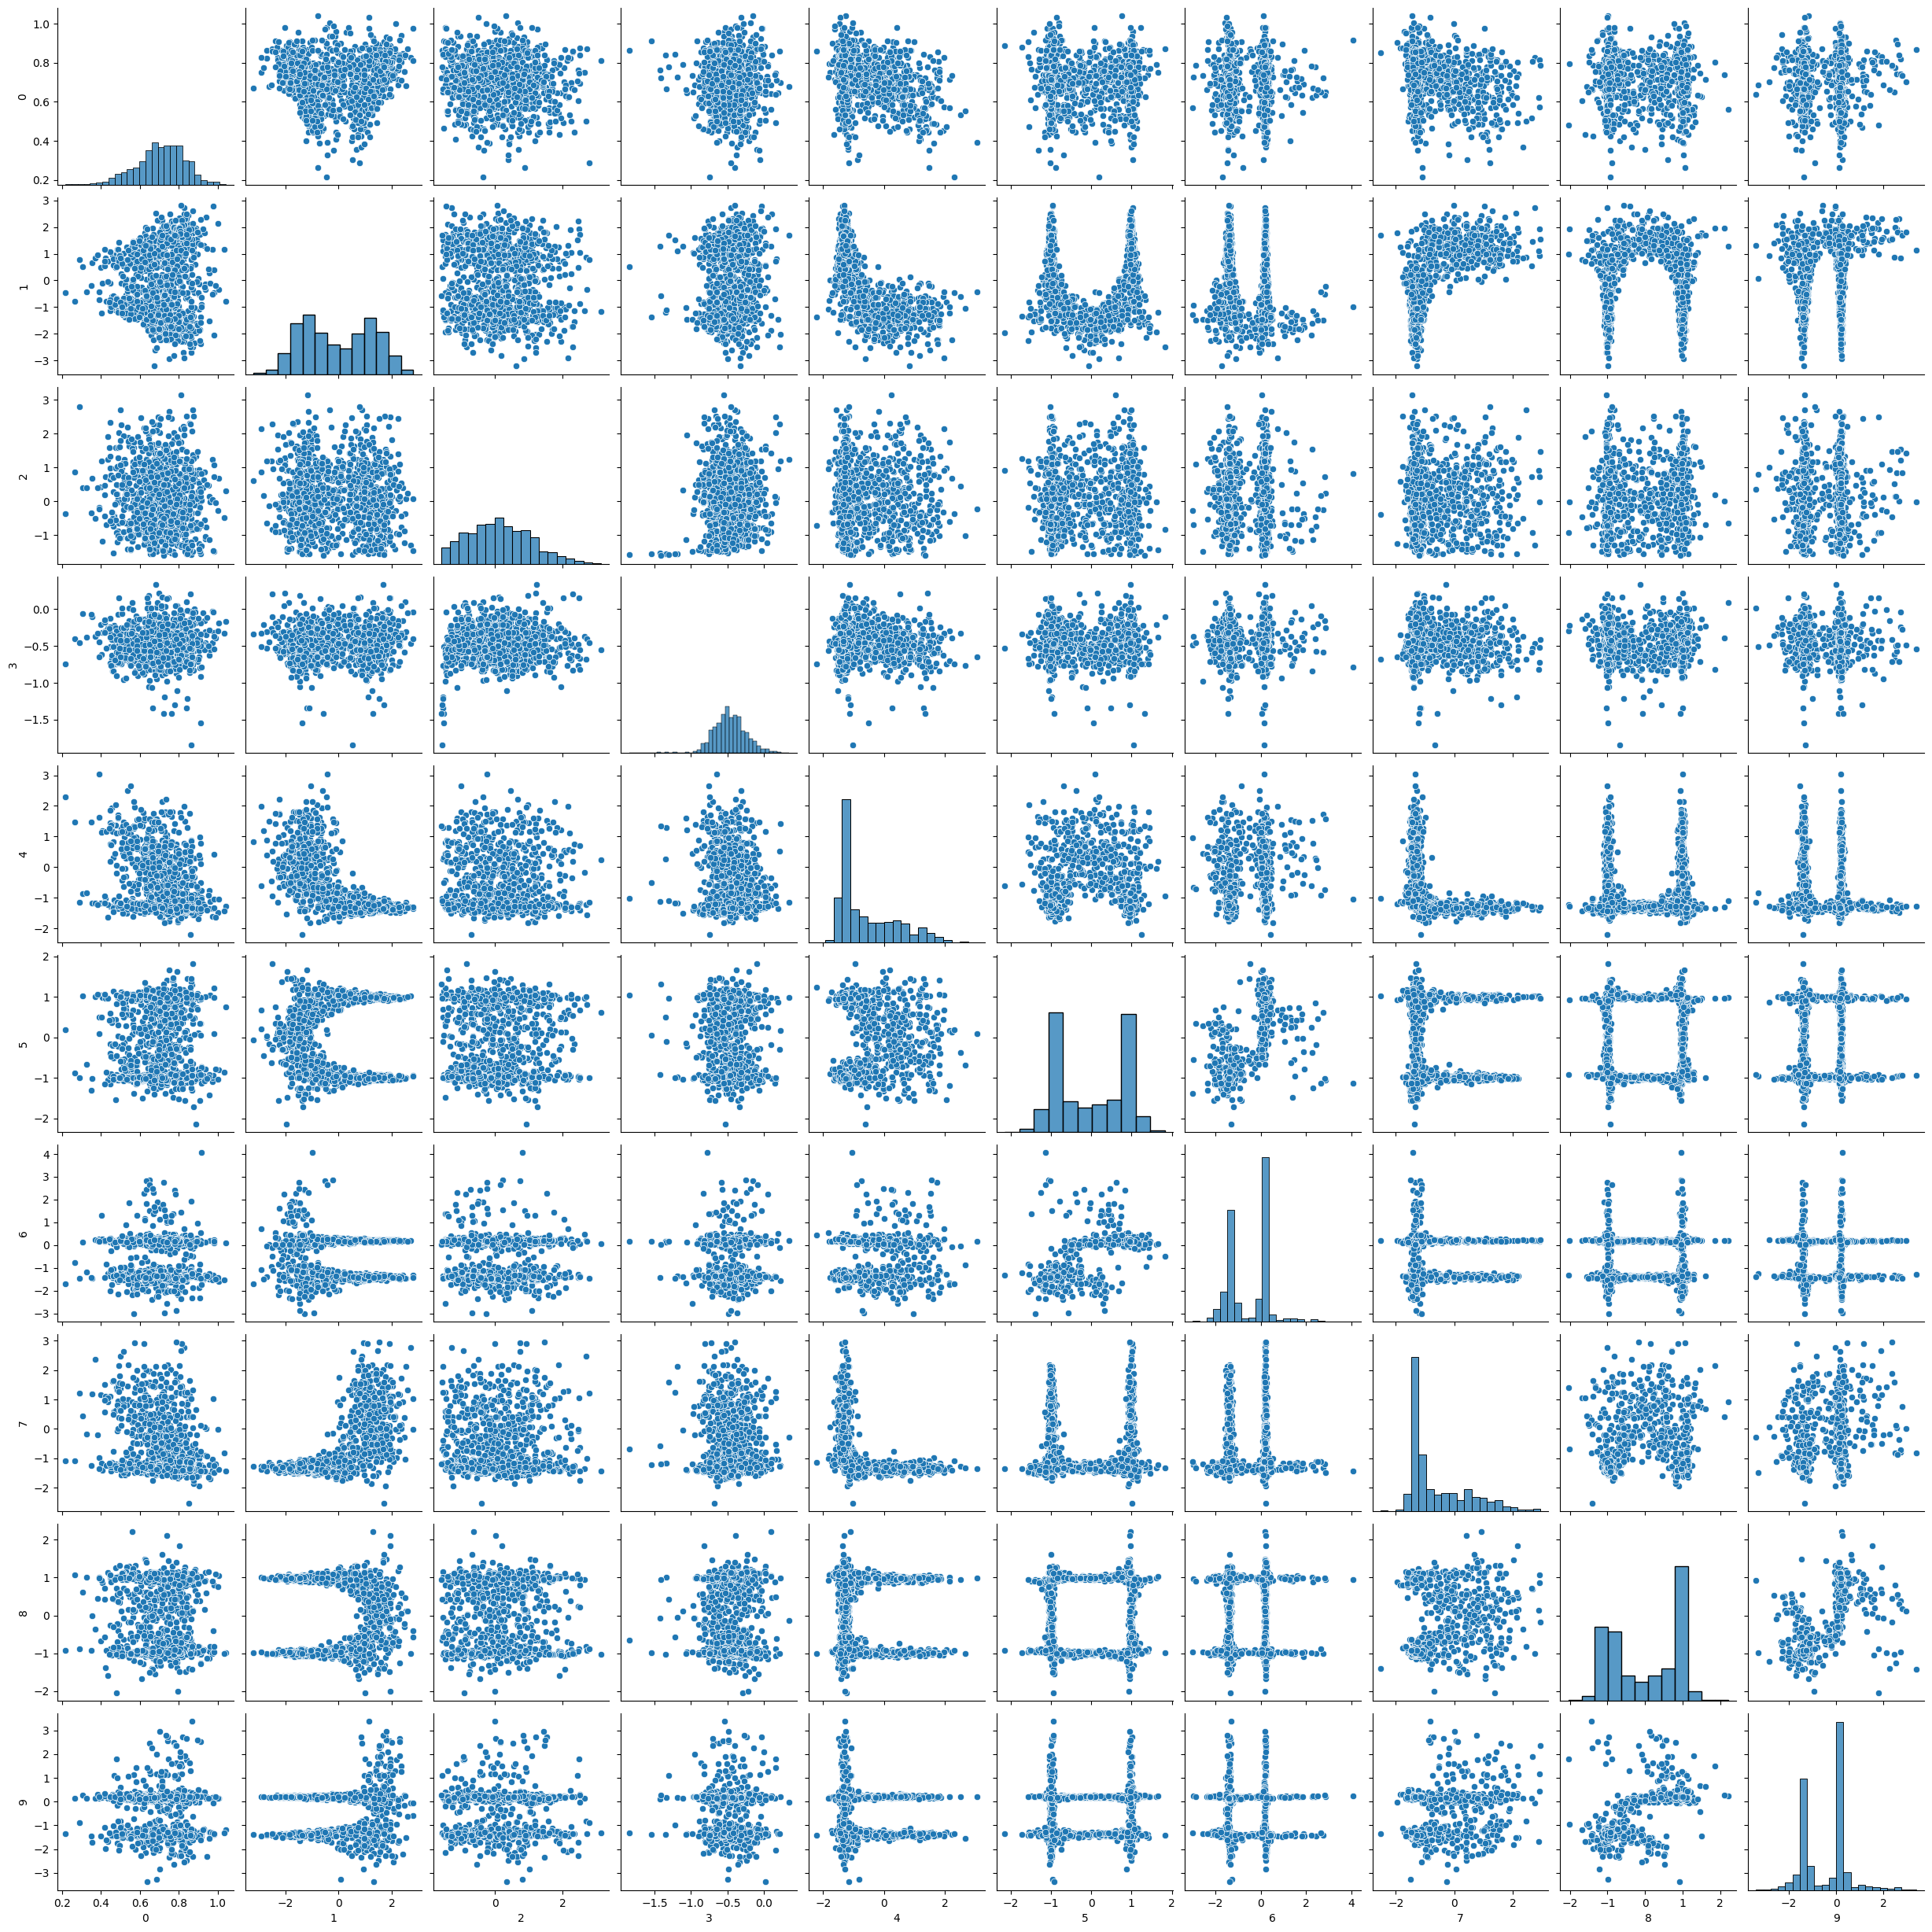

In [270]:
import seaborn as sns
import pandas as pd

sns.pairplot(pd.DataFrame(thetas_pred.reshape(-1, thetas_pred.shape[-1])))

In [259]:
def pred(key, thetas):
    params = unflatten(thetas)
    f = nnx.merge(graphdef, params)
    S = f(component_mask, bvals, bvecs, key)
    return S

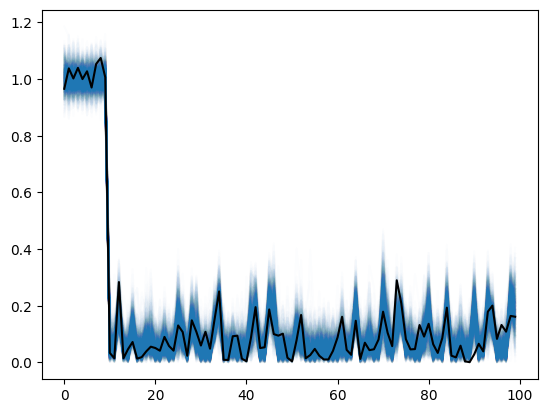

In [260]:
S_pred = jax.vmap(pred)(jax.random.split(jax.random.key(0),1000), thetas_pred)

plt.plot(S_pred.T, alpha=0.01, color="C0")
plt.plot(xs[idx], color="black")